# 01 — Correlation Engine

**Purpose:** Build rolling correlations across the full asset universe, score pair stability, detect breakdowns, compute tradeability scores, and run lead-lag analysis. Export results to `research/outputs/correlation_state.json` for the dashboard.

**Run time:** ~2–4 minutes on the full 100+ ticker universe (dominated by yfinance fetch).

**Output:** `research/outputs/correlation_state.json`

---
**Sections:**
1. Setup & data fetch
2. Rolling correlation matrices (30d / 90d / 180d)
3. Stability scoring
4. Breakdown detection
5. Tradeability scoring
6. Lead-lag analysis (held tickers only)
7. Visualisations
8. Export to JSON

## 1. Setup & data fetch

In [1]:
import sys
import os
import json
import logging
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Path setup: allow imports from both research/src and portfolio/src ──
NOTEBOOK_DIR  = os.path.abspath('')
RESEARCH_ROOT = os.path.join(NOTEBOOK_DIR, '..')
PORTFOLIO_ROOT = os.path.join(RESEARCH_ROOT, '..', '..', 'portfolio')

sys.path.insert(0, PORTFOLIO_ROOT)
sys.path.insert(0, RESEARCH_ROOT)

# ── Research imports ──
from src.config import (
    ASSET_UNIVERSE, BENCHMARK_TICKER, LOOKBACK_DAYS, RISK_FREE_RATE,
    ROLLING_WINDOWS, CORRELATION_BREAKDOWN_THRESHOLD, MIN_CORRELATION_THRESHOLD,
    MAX_STABILITY_STD, TOP_PAIRS_N, MAX_LAG_DAYS, OUTPUT_CORRELATION,
)
from src.correlation import (
    latest_correlation_matrix,
    compute_stability_scores,
    detect_correlation_breakdowns,
    compute_tradeability_scores,
    compute_lead_lag,
)

# ── Portfolio data layer (shared, read-only) ──
from src.data_loader import (
    fetch_historical,
    calculate_log_returns,
    fetch_fx_rate,
    convert_usd_prices_to_eur,
    load_ledger,
)

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

# ── Plotting style ──
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
})

print('✅ Imports OK')
print(f'   Asset universe : {len(ASSET_UNIVERSE)} tickers')
print(f'   Lookback       : {LOOKBACK_DAYS} trading days (~2 years)')
print(f'   Rolling windows: {ROLLING_WINDOWS} days')
print(f'   Output path    : {OUTPUT_CORRELATION}')

✅ Imports OK
   Asset universe : 102 tickers
   Lookback       : 504 trading days (~2 years)
   Rolling windows: [30, 90, 180] days
   Output path    : C:\Users\ahmty\Desktop\hedge-fund\ml_quant_finance_research\general_research\notebooks\..\src\..\outputs\correlation_state.json


In [2]:
# ── Fetch prices (uses portfolio cache at portfolio/data/historical_prices.csv
#    if available, otherwise fetches fresh from yfinance) ──

CACHE_PATH = os.path.join(PORTFOLIO_ROOT, 'data', 'historical_prices.csv')

print('Fetching market data...')
prices_raw = fetch_historical(
    tickers     = ASSET_UNIVERSE,
    lookback_days = LOOKBACK_DAYS,
    cache_path  = CACHE_PATH,
)

# Convert USD tickers to EUR (same logic as recalculate_engine.py)
usd_eur = fetch_fx_rate('USD', 'EUR')
prices  = convert_usd_prices_to_eur(prices_raw, usd_eur)

# Log returns
log_returns = calculate_log_returns(prices)

print(f'\n✅ Data ready')
print(f'   Price shape    : {prices.shape}')
print(f'   Returns shape  : {log_returns.shape}')
print(f'   Date range     : {log_returns.index[0].date()} → {log_returns.index[-1].date()}')
print(f'   USD/EUR rate   : {usd_eur:.4f}')

INFO: Fetching data for 102 assets from Yahoo Finance...


Fetching market data...


INFO: Data cached to C:\Users\ahmty\Desktop\hedge-fund\ml_quant_finance_research\general_research\notebooks\..\..\..\portfolio\data\historical_prices.csv (102/102 active tickers)


C:\Users\ahmty\Desktop\hedge-fund\ml_quant_finance_research\general_research\notebooks\..\..\..\portfolio\src\data_loader.py:177: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rate  = float(close.iloc[-1])   # .iloc[-1] avoids FutureWarning from float(Series)
INFO: FX Rate fetched: 1 USD = 0.8493 EUR


INFO:   Converted AMZN: USD → EUR @ 0.8493


...

INFO:   Converted HON: USD → EUR @ 0.8493


INFO:   Converted UPS: USD → EUR @ 0.8493


INFO:   Converted DE: USD → EUR @ 0.8493


INFO: Currency conversion applied to 62 non-EUR tickers.



✅ Data ready
   Price shape    : (426, 102)
   Returns shape  : (425, 102)
   Date range     : 2024-09-12 → 2026-05-07
   USD/EUR rate   : 0.8493


In [3]:
# ── Identify held tickers from ledger ──
# Lead-lag and some visualisations focus on held positions only.

LEDGER_PATH = os.path.join(PORTFOLIO_ROOT, 'data', 'ledger.csv')
holdings, cash = load_ledger(LEDGER_PATH)

# Filter to tickers that are both held and have return data
held_tickers = [t for t in holdings.keys() if t in log_returns.columns]

print(f'✅ Ledger loaded')
print(f'   Holdings       : {len(holdings)} tickers')
print(f'   Held + in data : {len(held_tickers)} tickers')
print(f'   Cash           : €{cash:,.2f}')
print(f'   Held tickers   : {held_tickers}')

INFO: Ledger loaded. Cash: €150.42, Holdings: 5 assets.


✅ Ledger loaded
   Holdings       : 5 tickers
   Held + in data : 5 tickers
   Cash           : €150.42
   Held tickers   : ['APC.DE', 'MSF.DE', 'AMZN', 'TSLA', 'ATAI']


## 2. Rolling correlation matrices

In [4]:
# Compute latest correlation matrices at each rolling window
# (latest snapshot only — fast)

corr_matrices = {}
for w in ROLLING_WINDOWS:
    corr_matrices[w] = latest_correlation_matrix(log_returns, window=w)
    print(f'  Window {w:3d}d: correlation matrix {corr_matrices[w].shape}')

print('\n✅ Rolling correlation matrices computed')

  Window  30d: correlation matrix (102, 102)
  Window  90d: correlation matrix (102, 102)
  Window 180d: correlation matrix (102, 102)

✅ Rolling correlation matrices computed


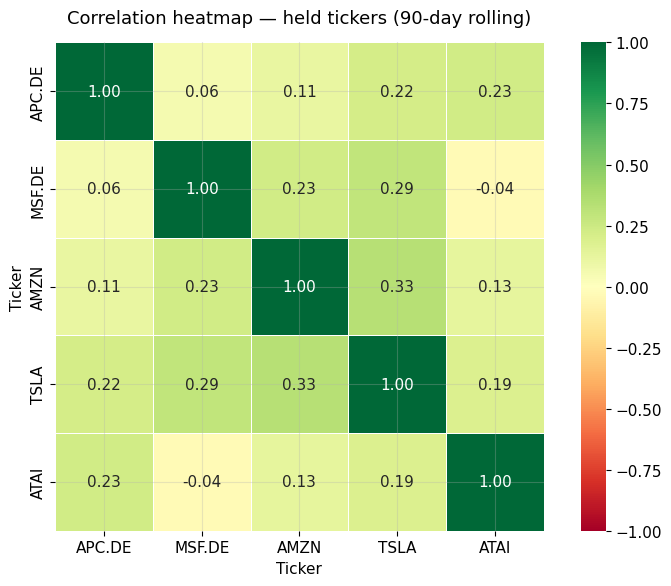

In [5]:
# ── Visualise: correlation heatmap for held tickers (90d window) ──

if len(held_tickers) >= 2:
    corr_held_90 = log_returns[held_tickers].tail(90).corr()

    fig, ax = plt.subplots(figsize=(max(8, len(held_tickers)), max(6, len(held_tickers) * 0.8)))
    mask = np.triu(np.ones_like(corr_held_90, dtype=bool), k=1)

    sns.heatmap(
        corr_held_90,
        ax       = ax,
        annot    = True,
        fmt      = '.2f',
        cmap     = 'RdYlGn',
        vmin     = -1,
        vmax     = 1,
        linewidths = 0.5,
        square   = True,
    )
    ax.set_title('Correlation heatmap — held tickers (90-day rolling)', pad=14, fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('⚠️  Fewer than 2 held tickers in data — skipping heatmap.')
    print('   (Run recalculate_engine.py first, or add entries to ledger.csv)')

## 3. Stability scoring

For every pair in the universe, measures the standard deviation of its 90-day rolling correlation over time.
Low std = stable relationship. High std = correlation flips around — dangerous for hedging.

In [6]:
print('Computing stability scores (this takes ~30–60s for 100+ tickers)...')
stability_df = compute_stability_scores(log_returns, window=90)

print(f'\n✅ Stability scores computed for {len(stability_df)} pairs')
print(f'   Most stable (top 10):')
display(stability_df.head(10))

print(f'\n   Most unstable (bottom 10):')
display(stability_df.tail(10))

Computing stability scores (this takes ~30–60s for 100+ tickers)...


INFO: Stability scores computed for 5151 pairs (window=90d)



✅ Stability scores computed for 5151 pairs
   Most stable (top 10):


,ticker_a,ticker_b,mean_corr,std_corr,stability_score
0,EUNL.DE,XDWD.DE,0.9992,0.0002,0.9998
1,EUNL.DE,SPPW.DE,0.9992,0.0002,0.9998
2,SPPW.DE,XDWD.DE,0.9989,0.0003,0.9997
3,VWCE.DE,XDWD.DE,0.9948,0.0025,0.9975
4,VWCE.DE,SPPW.DE,0.9944,0.0027,0.9973
5,EUNL.DE,VWCE.DE,0.9948,0.0028,0.9972
6,VUSA.DE,XDWD.DE,0.9848,0.0079,0.9921
7,EUNL.DE,VUSA.DE,0.9854,0.0081,0.9919
8,VUSA.DE,SPPW.DE,0.9850,0.0083,0.9917
9,EXS1.DE,DBXD.DE,0.9917,0.0131,0.9869



   Most unstable (bottom 10):


,ticker_a,ticker_b,mean_corr,std_corr,stability_score
5141,CRM,CAT,0.2578,0.3117,0.6883
5142,BP.L,IUSN.DE,0.2408,0.3119,0.6881
5143,ORCL,V,0.0798,0.3122,0.6878
5144,MU,CVX,0.1616,0.3129,0.6871
5145,VUSA.DE,EXXT.DE,0.7675,0.3161,0.6839
5146,NOW,CAT,0.2619,0.3219,0.6781
5147,ORCL,AXP,0.2650,0.3254,0.6746
5148,ORCL,CON.DE,-0.1681,0.3284,0.6716
5149,ADBE,CAT,0.1707,0.3389,0.6611
5150,CRM,GE,0.1715,0.3562,0.6438


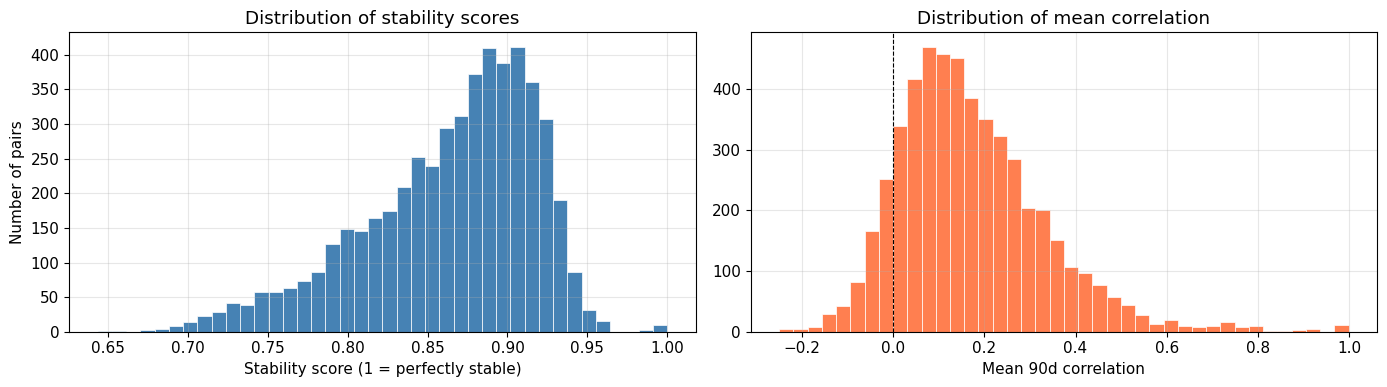

In [7]:
# ── Visualise: distribution of stability scores ──

if not stability_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(stability_df['stability_score'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[0].set_title('Distribution of stability scores')
    axes[0].set_xlabel('Stability score (1 = perfectly stable)')
    axes[0].set_ylabel('Number of pairs')

    axes[1].hist(stability_df['mean_corr'], bins=40, color='coral', edgecolor='white', linewidth=0.5)
    axes[1].set_title('Distribution of mean correlation')
    axes[1].set_xlabel('Mean 90d correlation')
    axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    plt.show()

## 4. Breakdown detection

Flags pairs where 30-day correlation has diverged from 90-day correlation by more than the threshold.
- **Compressing**: assets moving together more than usual → possible crisis signal
- **Decoupling**: relationship weakening → hedge may be breaking

In [8]:
breakdown_alerts = detect_correlation_breakdowns(
    log_returns,
    short_window = 30,
    long_window  = 90,
    threshold    = CORRELATION_BREAKDOWN_THRESHOLD,
)

print(f'✅ Breakdown detection complete')
print(f'   Total alerts : {len(breakdown_alerts)}')

if breakdown_alerts:
    alerts_df = pd.DataFrame(breakdown_alerts)
    print(f'   High severity: {len(alerts_df[alerts_df.severity=="high"])} pairs')
    print(f'\n   Top 15 breakdown pairs:')
    display(alerts_df.head(15))
else:
    print('   No significant breakdowns detected at current threshold.')

INFO: Breakdown detection: 1320 alerts flagged (threshold=0.2)


✅ Breakdown detection complete
   Total alerts : 1320
   High severity: 507 pairs

   Top 15 breakdown pairs:


,ticker_a,ticker_b,corr_short,corr_long,spread,direction,severity
0,BAS.DE,VOW3.DE,-0.4082,0.4085,-0.8168,decoupling,high
1,BAS.DE,HEN3.DE,-0.3680,0.3133,-0.6813,decoupling,high
2,BAS.DE,MBG.DE,-0.3607,0.3107,-0.6714,decoupling,high
3,BAS.DE,CON.DE,-0.4336,0.2280,-0.6616,decoupling,high
4,BMW.DE,BAS.DE,-0.2186,0.3869,-0.6056,decoupling,high
5,XOM,HON,-0.6557,-0.0960,-0.5598,decoupling,high
6,BEI.DE,GS,0.5462,0.0022,0.5440,compressing,high
7,BAS.DE,IUSN.DE,-0.3775,0.1658,-0.5433,decoupling,high
8,BEI.DE,XOM,-0.5052,0.0376,-0.5428,decoupling,high
9,NOV.DE,UNH,-0.4938,0.0462,-0.5400,decoupling,high


## 5. Tradeability scoring

Combines correlation strength (0–4 pts), stability (0–3 pts), and volatility compatibility (0–3 pts)
into a single 0–10 score per pair. Tags each pair as `hedge`, `stat-arb`, or `monitor`.

In [9]:
tradeability_df = compute_tradeability_scores(
    log_returns,
    stability_df,
    min_abs_corr = MIN_CORRELATION_THRESHOLD,
)

print(f'✅ Tradeability scoring complete')
print(f'   Pairs scored  : {len(tradeability_df)}')

if not tradeability_df.empty:
    tag_counts = tradeability_df['tag'].value_counts()
    for tag, count in tag_counts.items():
        print(f'   {tag:10s}: {count} pairs')

    print(f'\n   Top {TOP_PAIRS_N} tradeable pairs:')
    display(tradeability_df.head(TOP_PAIRS_N))

INFO: Tradeability scores: 254 pairs scored, 0 hedge, 83 stat-arb


✅ Tradeability scoring complete
   Pairs scored  : 254
   monitor   : 171 pairs
   stat-arb  : 83 pairs

   Top 20 tradeable pairs:


,ticker_a,ticker_b,mean_corr,stability_score,vol_a_ann,vol_b_ann,vol_compat,tradeability,tag
0,GS,MS,0.8829,0.9406,0.3111,0.3067,0.9859,9.31,stat-arb
1,V,MA,0.8805,0.9473,0.2251,0.2203,0.9785,9.30,stat-arb
2,HD,LOW,0.8767,0.9479,0.2300,0.2485,0.9255,9.13,stat-arb
3,XOM,CVX,0.8133,0.9205,0.2395,0.2379,0.9933,8.99,stat-arb
4,BMW.DE,MBG.DE,0.8452,0.9348,0.3007,0.2726,0.9068,8.91,stat-arb
5,JPM,BAC,0.7749,0.9226,0.2512,0.2570,0.9775,8.80,stat-arb
6,SHELL.AS,TTE.PA,0.7397,0.8947,0.2198,0.2201,0.9984,8.64,stat-arb
7,MBG.DE,VOW3.DE,0.7284,0.8704,0.2726,0.2705,0.9922,8.50,stat-arb
8,BAC,MS,0.7818,0.9272,0.2570,0.3067,0.8379,8.42,stat-arb
9,JPM,GS,0.7878,0.8938,0.2512,0.3111,0.8074,8.25,stat-arb


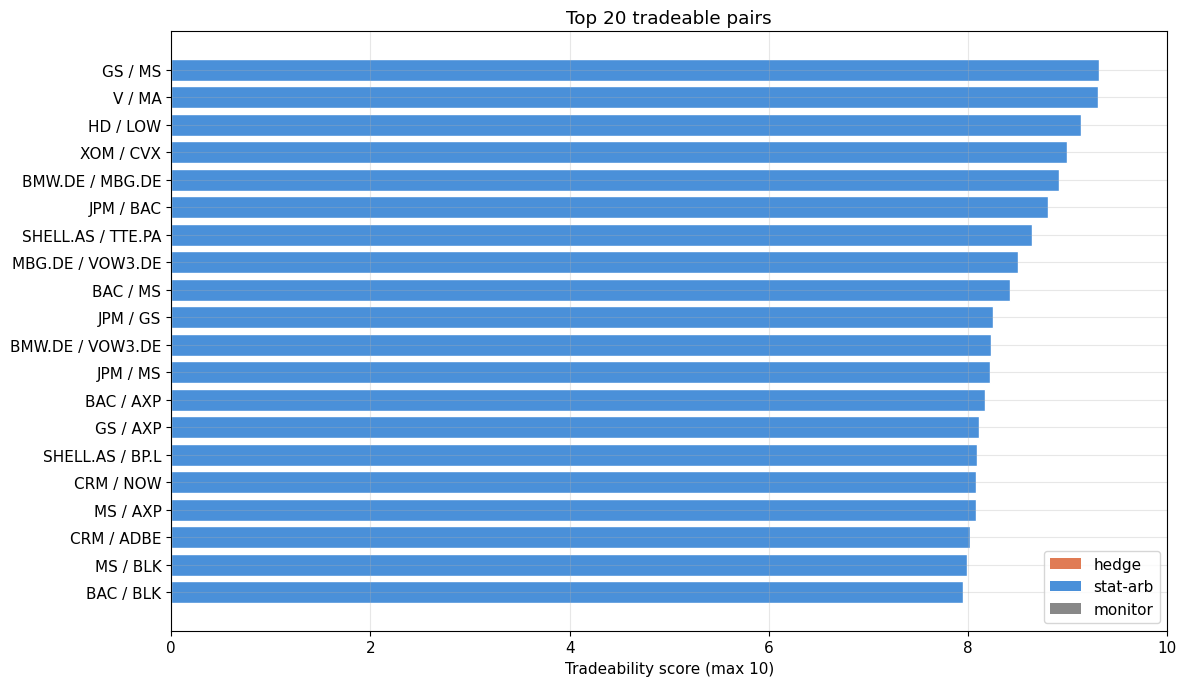

In [10]:
# ── Visualise: top 20 pairs by tradeability score ──

if not tradeability_df.empty:
    top = tradeability_df.head(TOP_PAIRS_N).copy()
    top['pair'] = top['ticker_a'] + ' / ' + top['ticker_b']

    color_map = {'hedge': '#E07B54', 'stat-arb': '#4A90D9', 'monitor': '#888'}
    colors = top['tag'].map(color_map).tolist()

    fig, ax = plt.subplots(figsize=(12, 7))
    bars = ax.barh(top['pair'][::-1], top['tradeability'][::-1], color=colors[::-1], edgecolor='white')
    ax.set_xlabel('Tradeability score (max 10)')
    ax.set_title(f'Top {TOP_PAIRS_N} tradeable pairs')
    ax.set_xlim(0, 10)

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
    ax.legend(handles=legend_elements, loc='lower right')

    plt.tight_layout()
    plt.show()

## 6. Lead-lag analysis (held tickers)

Runs cross-correlation analysis on held tickers only (fast).
Identifies which assets move first — actionable alpha signal, not just hedging.

In [11]:
lead_lag_results = []

if len(held_tickers) >= 2:
    print(f'Running lead-lag on {len(held_tickers)} held tickers (max lag = {MAX_LAG_DAYS}d)...')
    lead_lag_results = compute_lead_lag(log_returns, held_tickers, max_lag=MAX_LAG_DAYS)

    print(f'\n✅ Lead-lag analysis complete')
    print(f'   Significant pairs: {len(lead_lag_results)}')

    if lead_lag_results:
        ll_df = pd.DataFrame(lead_lag_results)
        display(ll_df)
    else:
        print('   No significant lead-lag relationships found among held tickers.')
else:
    print('⚠️  Need at least 2 held tickers for lead-lag analysis.')
    print('   Skipping — will run on full universe in 05_lead_lag.ipynb')

INFO: Lead-lag: 0 significant pairs found (max_lag=5)


Running lead-lag on 5 held tickers (max lag = 5d)...

✅ Lead-lag analysis complete
   Significant pairs: 0
   No significant lead-lag relationships found among held tickers.


## 7. Rolling correlation of held pairs over time

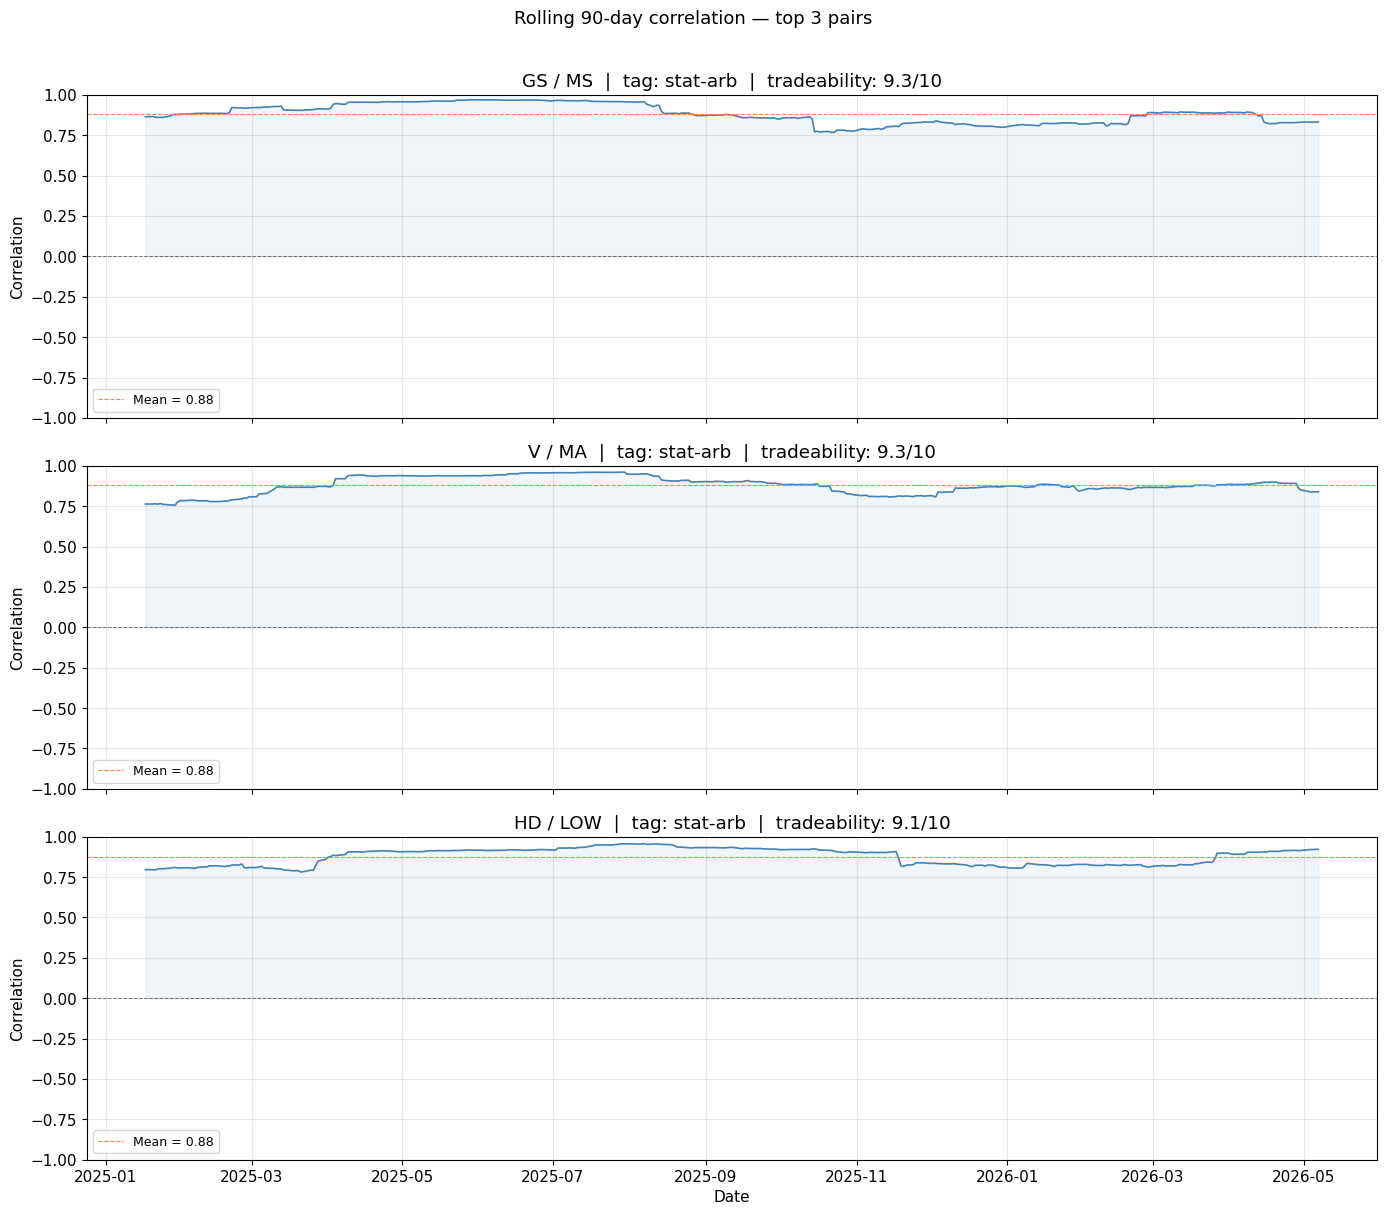

In [12]:
# ── Visualise: rolling 90-day correlation chart for top 3 tradeable pairs ──

if not tradeability_df.empty:
    top3 = tradeability_df.head(3)

    fig, axes = plt.subplots(len(top3), 1, figsize=(14, 4 * len(top3)), sharex=True)
    if len(top3) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, top3.iterrows()):
        a, b = row['ticker_a'], row['ticker_b']
        pair_returns = log_returns[[a, b]].dropna()
        rolling_corr = pair_returns[a].rolling(90).corr(pair_returns[b])

        ax.plot(rolling_corr.index, rolling_corr.values, linewidth=1.2, color='steelblue')
        ax.axhline(0, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
        ax.axhline(row['mean_corr'], color='coral', linestyle='--', linewidth=0.8,
                   label=f'Mean = {row["mean_corr"]:.2f}')
        ax.fill_between(rolling_corr.index, rolling_corr.values, alpha=0.08, color='steelblue')
        ax.set_ylabel('Correlation')
        ax.set_ylim(-1, 1)
        ax.set_title(f'{a} / {b}  |  tag: {row["tag"]}  |  tradeability: {row["tradeability"]:.1f}/10')
        ax.legend(fontsize=9)

    axes[-1].set_xlabel('Date')
    plt.suptitle('Rolling 90-day correlation — top 3 pairs', y=1.01, fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('No tradeability data to plot yet.')

## 8. Export to JSON

Writes `research/outputs/correlation_state.json` — the file read by the Flask server's
`/data/research_state.json` endpoint and rendered in the dashboard Research tab.

In [13]:
def df_to_records(df: pd.DataFrame, n: int = None) -> list:
    """Convert DataFrame to list of dicts, replacing NaN with None for JSON safety."""
    if df is None or df.empty:
        return []
    subset = df.head(n) if n else df
    return subset.where(pd.notna(subset), other=None).to_dict(orient='records')


# Build the JSON payload
state = {
    'generated_at':     datetime.now().isoformat(),
    'data_end_date':    str(log_returns.index[-1].date()),
    'n_tickers':        len(log_returns.columns),
    'held_tickers':     held_tickers,

    # Latest snapshot correlation matrices (held tickers only for dashboard)
    'corr_30d':         corr_matrices[30].loc[
                            [t for t in held_tickers if t in corr_matrices[30].index],
                            [t for t in held_tickers if t in corr_matrices[30].columns]
                        ].round(4).to_dict() if held_tickers else {},
    'corr_90d':         corr_matrices[90].loc[
                            [t for t in held_tickers if t in corr_matrices[90].index],
                            [t for t in held_tickers if t in corr_matrices[90].columns]
                        ].round(4).to_dict() if held_tickers else {},
    'corr_180d':        corr_matrices[180].loc[
                            [t for t in held_tickers if t in corr_matrices[180].index],
                            [t for t in held_tickers if t in corr_matrices[180].columns]
                        ].round(4).to_dict() if held_tickers else {},

    # Top tradeable pairs
    'top_pairs':        df_to_records(tradeability_df, n=TOP_PAIRS_N),

    # Breakdown alerts
    'breakdown_alerts': breakdown_alerts,

    # Lead-lag (held tickers)
    'lead_lag_pairs':   lead_lag_results,

    # Summary stats
    'summary': {
        'n_pairs_scored':       len(tradeability_df) if not tradeability_df.empty else 0,
        'n_hedge_pairs':        int((tradeability_df['tag'] == 'hedge').sum()) if not tradeability_df.empty else 0,
        'n_stat_arb_pairs':     int((tradeability_df['tag'] == 'stat-arb').sum()) if not tradeability_df.empty else 0,
        'n_breakdown_alerts':   len(breakdown_alerts),
        'n_lead_lag_pairs':     len(lead_lag_results),
        'top_pair':             f"{tradeability_df.iloc[0]['ticker_a']} / {tradeability_df.iloc[0]['ticker_b']}" if not tradeability_df.empty else None,
        'top_pair_score':       float(tradeability_df.iloc[0]['tradeability']) if not tradeability_df.empty else None,
    }
}

# Write output
os.makedirs(os.path.dirname(OUTPUT_CORRELATION), exist_ok=True)
with open(OUTPUT_CORRELATION, 'w', encoding='utf-8') as f:
    json.dump(state, f, indent=2, default=str)

print(f'✅ Exported to: {OUTPUT_CORRELATION}')
print(f'   File size: {os.path.getsize(OUTPUT_CORRELATION) / 1024:.1f} KB')
print(f'\nSummary:')
for k, v in state['summary'].items():
    print(f'   {k:30s}: {v}')

✅ Exported to: C:\Users\ahmty\Desktop\hedge-fund\ml_quant_finance_research\general_research\notebooks\..\src\..\outputs\correlation_state.json
   File size: 284.8 KB

Summary:
   n_pairs_scored                : 254
   n_hedge_pairs                 : 0
   n_stat_arb_pairs              : 83
   n_breakdown_alerts            : 1320
   n_lead_lag_pairs              : 0
   top_pair                      : GS / MS
   top_pair_score                : 9.31


---
## Done

`correlation_state.json` is now ready. Next steps:
- Add the `/data/research_state.json` endpoint to `portfolio/server.py`
- Add the Research Signals tab to `portfolio/dashboard.html`
- Run `02_regime_detection.ipynb` to populate `regime_state.json`